# Baseline Analysis

This notebook analyzes baseline misinformation spread across three network topologies with no fact checking intervention:

- **ER**: Erdős-Rényi random network
- **WS**: Watts–Strogatz small-world network
- **BA**: Barabási–Albert scale-free network

The main baseline question is: **Which topology spreads misinformation fastest before interventions are introduced?**


## Setup


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import f_oneway, ttest_ind

# This assumes the notebook is located in the notebooks/ folder.
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figure directory:", FIGURE_DIR)


Project root: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research
Data directory: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\data
Figure directory: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\figures


In [2]:
results_path = DATA_DIR / "baseline_results.csv"
curves_path = DATA_DIR / "baseline_curves.json"

print("Results file exists:", results_path.exists())
print("Curves file exists:", curves_path.exists())

results = pd.read_csv(results_path)
results.head()


Results file exists: True
Curves file exists: True


,topology,trial,n,beta,gamma,t10,t50,peak_infected,auc,final_size,duration
0,ER,0,1000,0.15,0.05,6,10,706,19207.5,0.986,153
1,ER,1,1000,0.15,0.05,5,9,725,20140.5,0.987,167
2,ER,2,1000,0.15,0.05,5,9,746,20514.5,0.994,140
3,ER,3,1000,0.15,0.05,7,11,711,19102.5,0.991,136
4,ER,4,1000,0.15,0.05,6,10,720,19185.5,0.991,162


These checks confirm that each topology has the expected number of trials and that key metrics are available.


In [3]:
print("Rows:", len(results))
print("Columns:", list(results.columns))

results.groupby("topology").size()


Rows: 300
Columns: ['topology', 'trial', 'n', 'beta', 'gamma', 't10', 't50', 'peak_infected', 'auc', 'final_size', 'duration']


topology
BA    100
ER    100
WS    100
dtype: int64

In [4]:
# Missing-value check
results.isna().sum()


topology         0
trial            0
n                0
beta             0
gamma            0
t10              0
t50              0
peak_infected    0
auc              0
final_size       0
duration         0
dtype: int64

In [5]:
# Check whether any trials did not reach 10% or 50% infection.
reached_table = results.assign(
    reached_10=results["t10"].notna(),
    reached_50=results["t50"].notna()
).groupby("topology")[["reached_10", "reached_50"]].mean()

reached_table


,reached_10,reached_50
topology,,
BA,1.0,1.0
ER,1.0,1.0
WS,1.0,1.0


Lower `t10` and `t50` mean faster spread. Higher `peak_infected`, `final_size`, and `auc` indicate larger or more intense outbreaks.


In [6]:
summary = results.groupby("topology")[[
    "t10",
    "t50",
    "peak_infected",
    "final_size",
    "auc"
]].agg(["mean", "std", "median"])

summary


t10                     t50                  peak_infected  \
          mean       std median   mean       std median          mean   
topology                                                                
BA        4.76  0.975663    5.0   7.90  1.000000    8.0        738.21   
ER        6.14  0.778758    6.0  10.41  0.888706   10.0        728.26   
WS        8.73  1.153431    9.0  17.76  1.511705   18.0        639.02   

                           final_size                        auc              \
                std median       mean       std median      mean         std   
topology                                                                       
BA        15.577305  739.0    0.99501  0.002699  0.995  19825.07  676.544970   
ER        15.224661  728.5    0.99041  0.003397  0.991  19844.99  530.899665   
WS        21.357931  638.0    0.99961  0.000650  1.000  19906.70  634.582086   

                   
           median  
topology           
BA        19834.0  
ER        19852.5  
WS        19875.5

In [7]:
# Cleaner table of means only for quick interpretation.
mean_summary = results.groupby("topology")[[
    "t10",
    "t50",
    "peak_infected",
    "final_size",
    "auc"
]].mean().sort_values("t50")

mean_summary


,t10,t50,peak_infected,final_size,auc
topology,,,,,
BA,4.76,7.90,738.21,0.99501,19825.07
ER,6.14,10.41,728.26,0.99041,19844.99
WS,8.73,17.76,639.02,0.99961,19906.70


## Figure 1 — Time to 10% infection

This measures early spread speed.


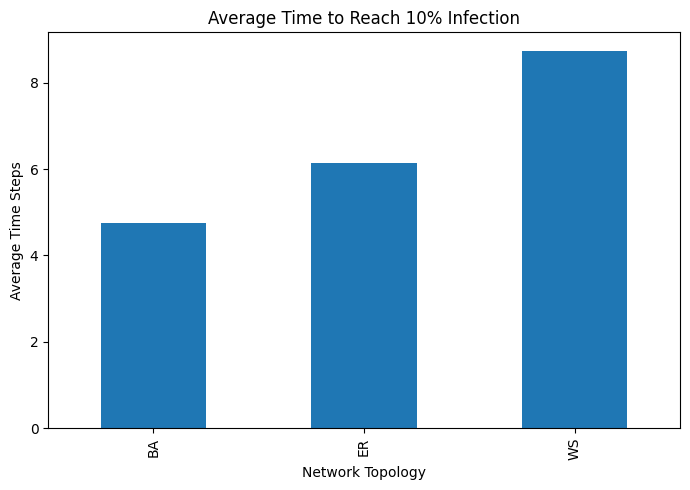

topology
BA    4.76
ER    6.14
WS    8.73
Name: t10, dtype: float64

In [8]:
plot_data = results.groupby("topology")["t10"].mean().sort_values()

ax = plot_data.plot(kind="bar", figsize=(7, 5))
ax.set_ylabel("Average Time Steps")
ax.set_xlabel("Network Topology")
ax.set_title("Average Time to Reach 10% Infection")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_t10_bar.png", dpi=300)
plt.show()

plot_data


## Figure 2 — Time to 50% infection

This is the primary baseline spread speed metric.


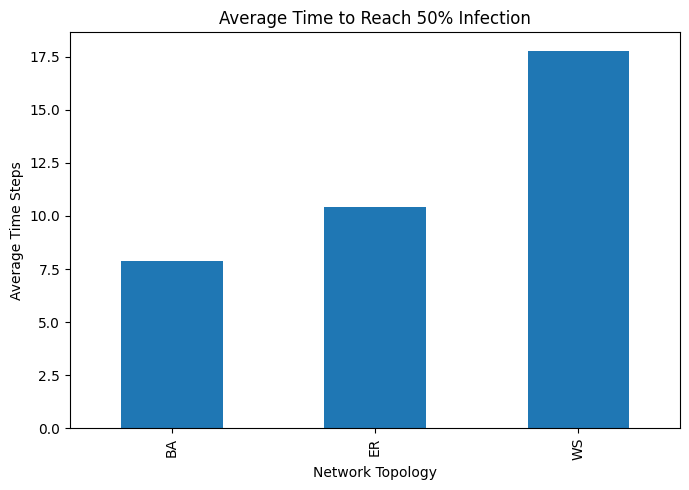

topology
BA     7.90
ER    10.41
WS    17.76
Name: t50, dtype: float64

In [9]:
plot_data = results.groupby("topology")["t50"].mean().sort_values()

ax = plot_data.plot(kind="bar", figsize=(7, 5))
ax.set_ylabel("Average Time Steps")
ax.set_xlabel("Network Topology")
ax.set_title("Average Time to Reach 50% Infection")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_t50_bar.png", dpi=300)
plt.show()

plot_data


## Figure 3 — Peak active spreaders

This measures the maximum number of nodes actively spreading misinformation at the same time.


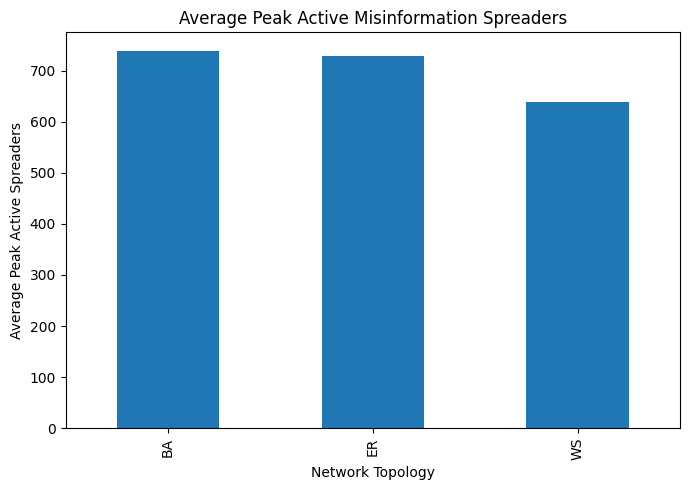

topology
BA    738.21
ER    728.26
WS    639.02
Name: peak_infected, dtype: float64

In [10]:
plot_data = results.groupby("topology")["peak_infected"].mean().sort_values(ascending=False)

ax = plot_data.plot(kind="bar", figsize=(7, 5))
ax.set_ylabel("Average Peak Active Spreaders")
ax.set_xlabel("Network Topology")
ax.set_title("Average Peak Active Misinformation Spreaders")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_peak_bar.png", dpi=300)
plt.show()

plot_data


## Figure 4 — Final outbreak size

This measures the fraction of nodes that were ever infected during the simulation.


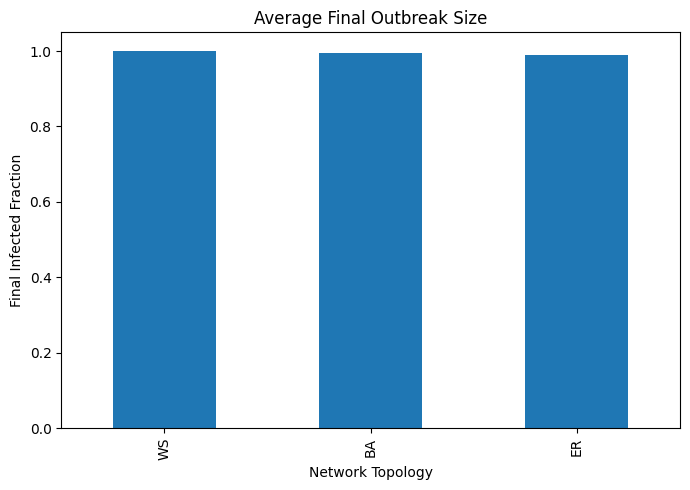

topology
WS    0.99961
BA    0.99501
ER    0.99041
Name: final_size, dtype: float64

In [11]:
plot_data = results.groupby("topology")["final_size"].mean().sort_values(ascending=False)

ax = plot_data.plot(kind="bar", figsize=(7, 5))
ax.set_ylabel("Final Infected Fraction")
ax.set_xlabel("Network Topology")
ax.set_title("Average Final Outbreak Size")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_final_size_bar.png", dpi=300)
plt.show()

plot_data


## Figure 5 — Area under infection curve

AUC approximates total misinformation burden over time. Higher AUC means more active spreaders over the full outbreak.


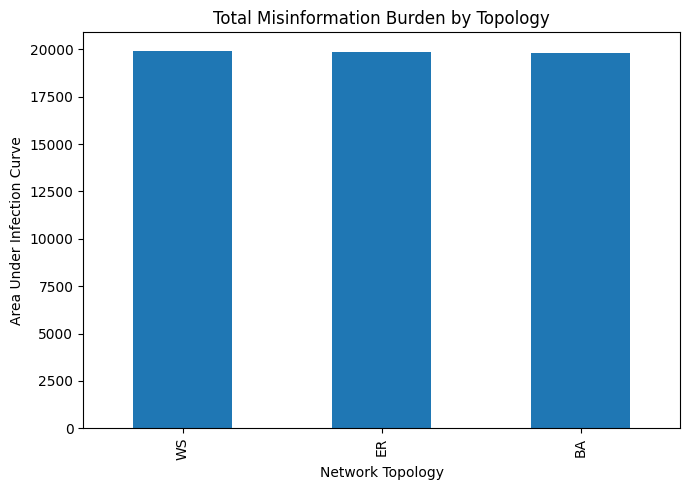

topology
WS    19906.70
ER    19844.99
BA    19825.07
Name: auc, dtype: float64

In [12]:
plot_data = results.groupby("topology")["auc"].mean().sort_values(ascending=False)

ax = plot_data.plot(kind="bar", figsize=(7, 5))
ax.set_ylabel("Area Under Infection Curve")
ax.set_xlabel("Network Topology")
ax.set_title("Total Misinformation Burden by Topology")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_auc_bar.png", dpi=300)
plt.show()

plot_data


Load and reshape infection curves


In [13]:
with open(curves_path, "r") as f:
    curves = json.load(f)

max_length = max(len(item["infected_counts"]) for item in curves)
curve_rows = []

for item in curves:
    curve = item["infected_counts"]
    padded_curve = curve + [0] * (max_length - len(curve))
    
    for t, infected in enumerate(padded_curve):
        curve_rows.append({
            "topology": item["topology"],
            "trial": item["trial"],
            "time": t,
            "infected": infected
        })

curve_df = pd.DataFrame(curve_rows)
curve_df.head()


,topology,trial,time,infected
0,ER,0,0,5
1,ER,0,1,11
2,ER,0,2,17
3,ER,0,3,30
4,ER,0,4,46


## Figure 6 — Average misinformation spread curves

Shows the full time course rather than only summary metrics.


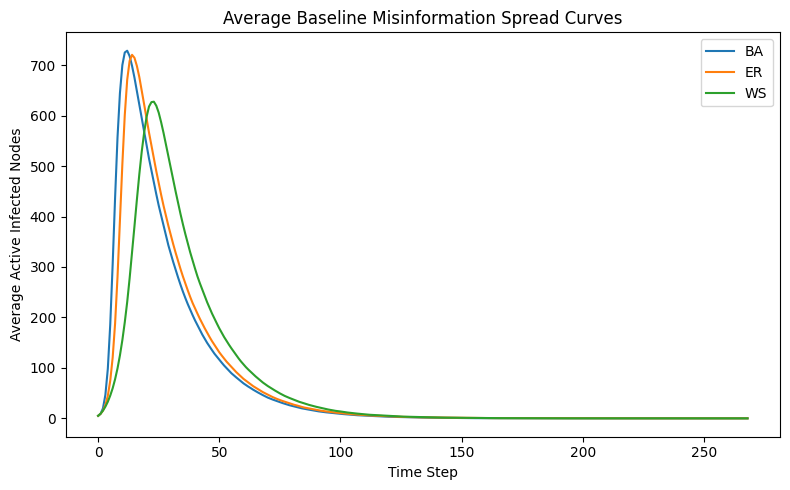

In [14]:
avg_curve = curve_df.groupby(["topology", "time"])["infected"].mean().reset_index()

plt.figure(figsize=(8, 5))
for topology in ["BA", "ER", "WS"]:
    subset = avg_curve[avg_curve["topology"] == topology]
    plt.plot(subset["time"], subset["infected"], label=topology)

plt.xlabel("Time Step")
plt.ylabel("Average Active Infected Nodes")
plt.title("Average Baseline Misinformation Spread Curves")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_average_curves.png", dpi=300)
plt.show()


These ANOVA tests t10, t50, peak_infected, final_size, and auc differ across the three topologies.


In [15]:
anova_results = []

metrics = ["t10", "t50", "peak_infected", "final_size", "auc"]

for metric in metrics:
    ba = results[results["topology"] == "BA"][metric].dropna()
    er = results[results["topology"] == "ER"][metric].dropna()
    ws = results[results["topology"] == "WS"][metric].dropna()

    f_stat, p_value = f_oneway(ba, er, ws)

    anova_results.append({
        "metric": metric,
        "F_statistic": f_stat,
        "p_value": p_value
    })

anova_table = pd.DataFrame(anova_results)

anova_table

,metric,F_statistic,p_value
0,t10,421.862058,1.633090e-87
1,t50,1933.009171,5.274685e-171
2,peak_infected,961.818204,1.788259e-130
3,final_size,329.901258,3.566316e-76
4,auc,0.475740,6.218979e-01


These checks are useful because threshold times are discrete and final outbreak size is bounded.

,Outcome,F,Raw p,eta_squared,Levene p,Welch ANOVA p,Kruskal-Wallis p,Holm p
0,Time to 10% infection,421.8621,0.0000,0.7396,0.0011,0.0000,0.0000,0.0000
1,Time to 50% infection,1933.0092,0.0000,0.9287,0.0000,0.0000,0.0000,0.0000
2,Peak active spreaders,961.8182,0.0000,0.8663,0.0029,0.0000,0.0000,0.0000
3,Final outbreak size,329.9013,0.0000,0.6896,0.0000,0.0000,0.0000,0.0000
4,Cumulative exposure (AUC),0.4757,0.6219,0.0032,0.1304,0.6438,0.7412,0.6219


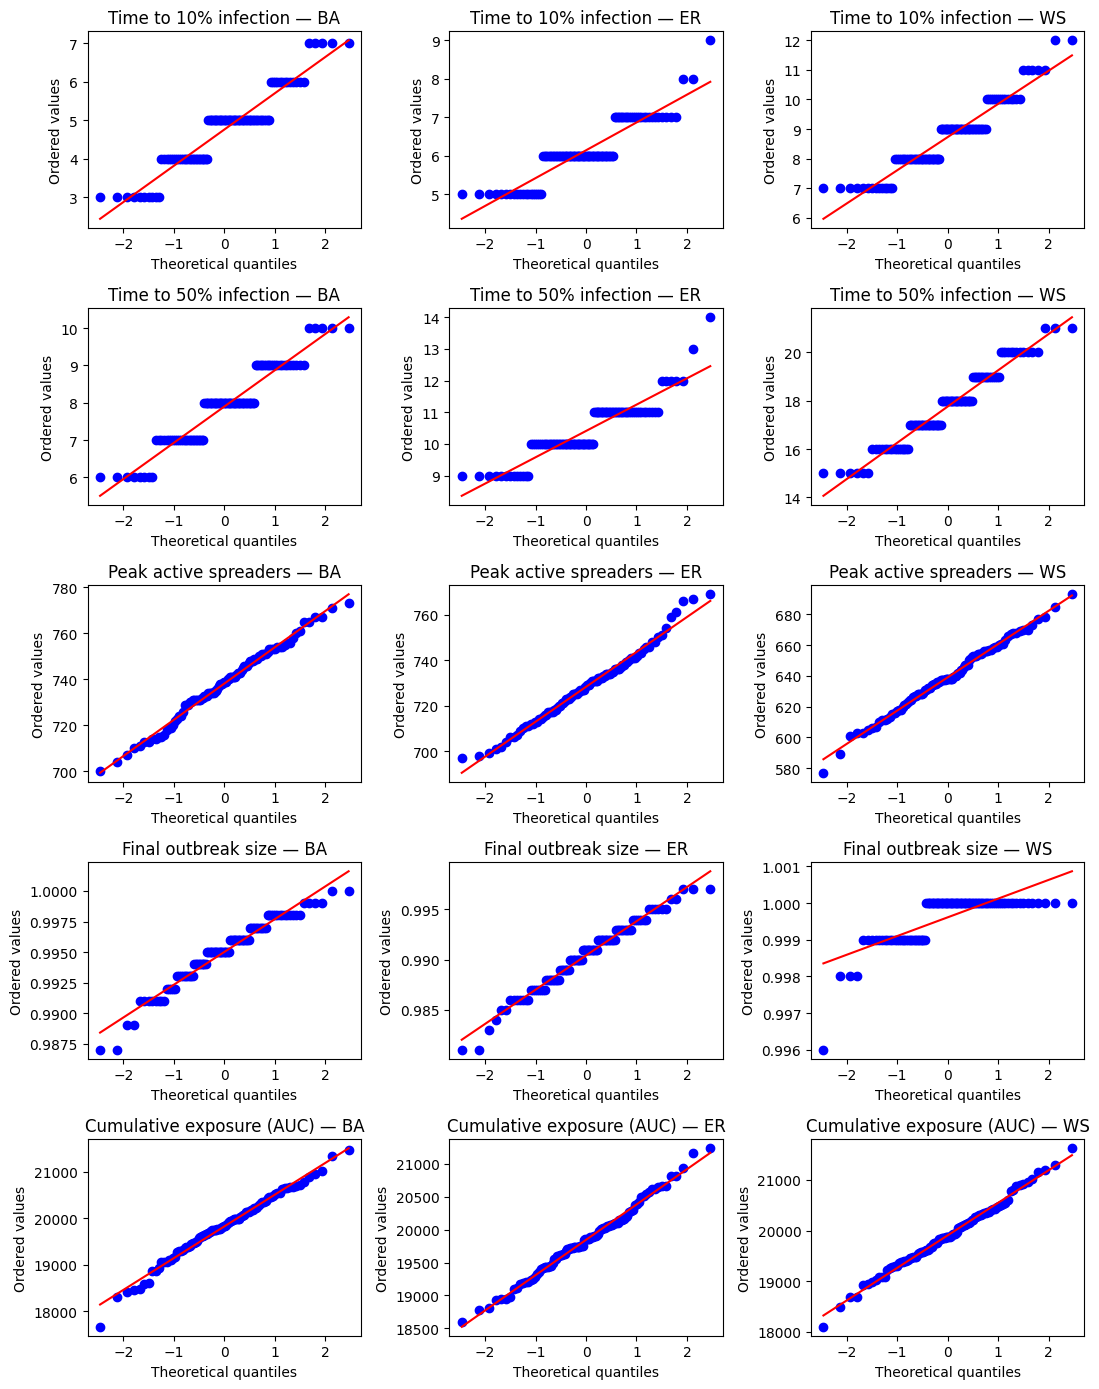

Saved: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\figures\baseline_qq_diagnostics.png


In [16]:
from scipy.stats import f_oneway, levene, kruskal, probplot
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.oneway import anova_oneway

metric_labels = {
    "t10": "Time to 10% infection",
    "t50": "Time to 50% infection",
    "peak_infected": "Peak active spreaders",
    "final_size": "Final outbreak size",
    "auc": "Cumulative exposure (AUC)",
}

diagnostic_rows = []
for metric in metric_labels:
    groups = [
        results.loc[results["topology"] == topology, metric].dropna()
        for topology in ["BA", "ER", "WS"]
    ]

    f_stat, p_value = f_oneway(*groups)
    df_between = len(groups) - 1
    df_within = sum(len(group) for group in groups) - len(groups)
    eta_squared = (
        (f_stat * df_between)
        / ((f_stat * df_between) + df_within)
    )

    diagnostic_rows.append({
        "Outcome": metric_labels[metric],
        "F": f_stat,
        "Raw p": p_value,
        "eta_squared": eta_squared,
        "Levene p": levene(*groups, center="median").pvalue,
        "Welch ANOVA p": anova_oneway(groups, use_var="unequal").pvalue,
        "Kruskal-Wallis p": kruskal(*groups).pvalue,
    })

baseline_diagnostics = pd.DataFrame(diagnostic_rows)
baseline_diagnostics["Holm p"] = multipletests(
    baseline_diagnostics["Raw p"],
    method="holm",
)[1]

display(baseline_diagnostics.round(4))

fig, axes = plt.subplots(
    nrows=len(metric_labels),
    ncols=3,
    figsize=(11, 14),
)

for row, metric in enumerate(metric_labels):
    for col, topology in enumerate(["BA", "ER", "WS"]):
        ax = axes[row, col]
        values = results.loc[
            results["topology"] == topology,
            metric,
        ].dropna()

        probplot(values, dist="norm", plot=ax)
        ax.set_title(f"{metric_labels[metric]} — {topology}")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Ordered values")

fig.tight_layout()
qq_path = FIGURE_DIR / "baseline_qq_diagnostics.png"
fig.savefig(qq_path, dpi=300, bbox_inches="tight")
plt.show()

baseline_diagnostics.to_csv(
    DATA_DIR / "baseline_statistical_diagnostics.csv",
    index=False,
)

print("Saved:", qq_path)